In [ ]:
!gcloud auth application-default login

In [1]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/18 14:11:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/18 14:11:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"

si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

In [4]:
coloc = session.spark.read.parquet("/users/yt4/Projects/releases/2506/colocalisation_coloc")
ecaviar = session.spark.read.parquet("/users/yt4/Projects/releases/2506/colocalisation_ecaviar")

# Clustering analysis


In [5]:
(
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets"
    ).count()
)

70618

In [25]:
def cluster_lead_variants(lead_variants_list, colocalisation_list):
    # Create a lookup for studyLocusId to the full data dictionary
    study_locus_info = {item["studyLocusId"]: item for item in lead_variants_list}

    # Create a lookup from variantId to a list of studyLocusIds
    variant_to_loci = {}
    for item in lead_variants_list:
        variant_id = item["leadVariantId"]
        if variant_id not in variant_to_loci:
            variant_to_loci[variant_id] = []
        variant_to_loci[variant_id].append(item["studyLocusId"])

    # Create a lookup for colocalisation
    coloc_lookup = {}
    for item in colocalisation_list:
        left_id = item["leftStudyLocusId"]
        right_id = item["rightStudyLocusId"]
        if left_id not in coloc_lookup:
            coloc_lookup[left_id] = set()
        if right_id not in coloc_lookup:
            coloc_lookup[right_id] = set()
        coloc_lookup[left_id].add(right_id)
        coloc_lookup[right_id].add(left_id)

    clusters = []
    used_loci = set()

    for lead_variant in lead_variants_list:
        start_locus_id = lead_variant["studyLocusId"]
        if start_locus_id in used_loci:
            continue

        # This locus is the seed for a new cluster
        cluster_loci_to_process = {start_locus_id}

        # This set will store all loci belonging to the current cluster
        final_cluster_loci = set()

        while cluster_loci_to_process:
            # Take a locus to process
            locus_id = cluster_loci_to_process.pop()

            # If already processed, skip
            if locus_id in used_loci:
                continue

            # Add to the final cluster and mark as used
            final_cluster_loci.add(locus_id)
            used_loci.add(locus_id)

            # 1. Find all colocalized loci and add them to the processing queue
            if locus_id in coloc_lookup:
                for neighbor in coloc_lookup[locus_id]:
                    if neighbor not in used_loci:
                        cluster_loci_to_process.add(neighbor)

            # 2. Find all loci with the same variant and add them to the processing queue
            if locus_id in study_locus_info:
                variant_id = study_locus_info[locus_id]["leadVariantId"]
                if variant_id in variant_to_loci:
                    for shared_variant_locus in variant_to_loci[variant_id]:
                        if shared_variant_locus not in used_loci:
                            cluster_loci_to_process.add(shared_variant_locus)

        # Final cluster with full info
        cluster_details = [
            study_locus_info[locus_id]
            for locus_id in final_cluster_loci
            if locus_id in study_locus_info
        ]

        if cluster_details:
            clusters.append(
                {
                    "cluster_id": len(clusters),
                    "lead_study_locus_id": start_locus_id,
                    "colocalised_study_loci": cluster_details,
                    "cluster_size": len(cluster_details),
                }
            )

    return clusters

In [27]:
lead_variants = (
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets"
    )
    .withColumn(
        "pValue",
        f.col("variantStatistics.pValueMantissa")
        * f.pow(10, f.col("variantStatistics.pValueExponent")),
    )
    .sort("pValue", f.desc("locusStatistics.leadVariantPIP"))
    .persist()
)

25/11/18 14:55:50 WARN CacheManager: Asked to cache already cached data.


In [28]:
lead_variants.count()

70618

In [29]:
lead_variants=lead_variants.join(si.df.select("studyId","publicationDate"), on="studyId", how="inner").cache()
lead_variants.count()

70618

In [30]:
lead_variants.show(1)

+------------+--------------+--------------------+--------------------+------+------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+------+---------+--------+------+---------------+
|     studyId|     variantId|             variant|        studyLocusId|geneId|originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|nCases|nControls|nSamples|pValue|publicationDate|
+------------+--------------+--------------------+--------------------+------+------------+---------------------+--------------------+-----------------+----------+--------------------+------

In [31]:
lead_variants = lead_variants.withColumn(
    "pub_date", f.to_date(f.col("publicationDate"), "yyyy-MM-dd")
).withColumn(
    "year", f.year(f.col("pub_date"))
)

In [32]:
lead_variants.show(1)

+------------+--------------+--------------------+--------------------+------+------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+------+---------+--------+------+---------------+----------+----+
|     studyId|     variantId|             variant|        studyLocusId|geneId|originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|nCases|nControls|nSamples|pValue|publicationDate|  pub_date|year|
+------------+--------------+--------------------+--------------------+------+------------+---------------------+--------------------+-----------------+------

25/11/18 15:00:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [33]:
lead_variants.filter(f.col("year").isNull()).count()

15075

In [34]:
lead_variants = lead_variants.fillna({"year": 2024}).cache()

In [35]:
lead_variants.filter(f.col("year").isNull()).count()

0

In [41]:
def select_year(year):
    import pyspark.sql.types as t
    from pyspark.sql.window import Window

    lead_varaint_year=lead_variants.filter(f.col("year")<=year).cache()
    study_loci_list = [
        {
            "studyLocusId": row["studyLocusId"],
            "leadVariantId": row["variantId"],
            "traitId": row["traitFromSourceMappedIds"],
        }
        for row in lead_varaint_year.select(
            "studyLocusId", "variantId", "traitFromSourceMappedIds"
        ).collect()
    ]
    study_locus_ids = [d["studyLocusId"] for d in study_loci_list]

    colocalisation = (
        coloc.unionByName(ecaviar, True)
        .filter((f.col("h4") >= 0.8) | (f.col("clpp") >= 0.01))
        .select("leftStudyLocusId", "rightStudyLocusId")
        .filter(
            f.col("leftStudyLocusId").isin(study_locus_ids)
            & f.col("rightStudyLocusId").isin(study_locus_ids)
        )
        .persist()
    )
    colocalisation_list = [
        {
            "leftStudyLocusId": row["leftStudyLocusId"],
            "rightStudyLocusId": row["rightStudyLocusId"],
        }
        for row in colocalisation.collect()
    ]
    clusters = cluster_lead_variants(study_loci_list, colocalisation_list)


    # Define the schema for the nested dictionary
    schema = t.StructType(
        [
            t.StructField("studyLocusId", t.StringType(), True),
            t.StructField("leadVariantId", t.StringType(), True),
            t.StructField("traitId", t.ArrayType(t.StringType()), True),
        ]
    )

    # Define the schema for the cluster data
    cluster_schema = t.StructType(
        [
            t.StructField("cluster_id", t.IntegerType(), True),
            t.StructField("lead_study_locus_id", t.StringType(), True),
            t.StructField("colocalised_study_loci", t.ArrayType(schema), True),
            t.StructField("cluster_size", t.IntegerType(), True),
        ]
    )

    clusters_df = session.spark.createDataFrame(clusters, schema=cluster_schema).select(
        "cluster_id", "lead_study_locus_id", "cluster_size", "colocalised_study_loci"
    )
    #clusters_df.agg(f.sum("cluster_size").alias("total_cluster_size")).show()


    clusters_with_trait_count = clusters_df.withColumn(
        "uniqueTraitsInCluster",
        f.size(f.array_distinct(f.flatten(f.col("colocalised_study_loci.traitId")))),
    )
    exploded_loci = clusters_with_trait_count.select(
        "cluster_id", f.explode("colocalised_study_loci").alias("locus")
    )
    variant_traits_in_cluster = exploded_loci.groupBy(
        "cluster_id", "locus.leadVariantId"
    ).agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("locus.traitId")))).alias(
            "uniqueTraitCountForVariant"
        )
    )
    window_spec = Window.partitionBy("cluster_id").orderBy(
        f.desc("uniqueTraitCountForVariant"), f.col("leadVariantId")
    )
    top_variant_per_cluster = (
        variant_traits_in_cluster.withColumn("row_num", f.row_number().over(window_spec))
        .filter(f.col("row_num") == 1)
        .select(
            f.col("cluster_id"),
            f.col("leadVariantId").alias("clusterVariantId"),
        )
    )
    result_df = (
        clusters_with_trait_count.join(top_variant_per_cluster, "cluster_id")
        .select(
            "cluster_id",
            "cluster_size",
            "colocalised_study_loci",
            "uniqueTraitsInCluster",
            "clusterVariantId",
        )
        .sort("cluster_id")
        .persist()
    )
    return result_df
    #result_df.show()

In [45]:
tmp=select_year(2015)

In [46]:
tmp.count()

1830

In [50]:
import math
import pandas as pd
import pyspark.sql.functions as f

stats = []
for year in range(2006, 2026):
    tmp = select_year(year)
    # aggregated stats
    agg = tmp.agg(
        f.count("*").alias("n_agg"),
        f.mean("uniqueTraitsInCluster").alias("mean"),
        f.stddev_samp("uniqueTraitsInCluster").alias("sd"),
    ).collect()[0]
    n_agg = int(agg["n_agg"])
    mean = float(agg["mean"]) if agg["mean"] is not None else None
    sd = float(agg["sd"]) if agg["sd"] is not None else 0.0
    se = sd / math.sqrt(n_agg) if n_agg > 0 else None

    # explicit count() as requested
    n_count = int(tmp.count())

    stats.append({"year": year, "mean": mean, "sd": sd, "se": se, "n_agg": n_agg, "n_count": n_count})

df_stats = pd.DataFrame(stats).sort_values("year").reset_index(drop=True)

25/11/18 15:31:50 WARN CacheManager: Asked to cache already cached data.        
25/11/18 15:31:54 WARN CacheManager: Asked to cache already cached data.
25/11/18 15:32:20 WARN DAGScheduler: Broadcasting large task binary with size 1241.7 KiB
25/11/18 15:32:28 WARN DAGScheduler: Broadcasting large task binary with size 1244.0 KiB
25/11/18 15:32:44 WARN DAGScheduler: Broadcasting large task binary with size 2017.1 KiB
25/11/18 15:32:56 WARN DAGScheduler: Broadcasting large task binary with size 2019.3 KiB
25/11/18 15:33:19 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/11/18 15:33:33 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/11/18 15:34:04 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
25/11/18 15:34:14 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
25/11/18 15:34:51 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
25/11/18 15:35:08 WARN DAGScheduler: Broadcasting large task

In [51]:
df_stats

,year,mean,sd,se,n_agg,n_count
0,2006,1.000000,0.000000,0.000000,1,1
1,2007,1.065217,0.249637,0.036807,46,46
2,2008,1.051852,0.253881,0.021851,135,135
3,2009,1.078067,0.319518,0.019481,269,269
4,2010,1.110092,0.379702,0.018184,436,436
5,2011,1.142020,0.425065,0.016265,683,683
6,2012,1.219512,0.641661,0.020042,1025,1025
7,2013,1.252471,0.772521,0.021303,1315,1315
8,2014,1.244094,0.751098,0.019240,1524,1524
9,2015,1.437705,1.487766,0.034778,1830,1830


In [1]:
df_stats

NameError: name 'df_stats' is not defined

In [54]:
df_stats.to_csv("cluster_stats_by_year.csv", index=False)

In [47]:
tmp.select("clusterVariantId").distinct().count()

1830

In [23]:
result_df.agg(
    f.max("uniqueTraitsInCluster"),
    f.mean("uniqueTraitsInCluster"),
    f.percentile("uniqueTraitsInCluster", [0.25, 0.5, 0.75]),
).show()

+--------------------------+--------------------------+------------------------------------------------------------+
|max(uniqueTraitsInCluster)|avg(uniqueTraitsInCluster)|percentile(uniqueTraitsInCluster, array(0.25, 0.5, 0.75), 1)|
+--------------------------+--------------------------+------------------------------------------------------------+
|                       122|         2.156080035926351|                                             [1.0, 1.0, 2.0]|
+--------------------------+--------------------------+------------------------------------------------------------+



In [18]:
variant_pleiotropy_clustered = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/variant_pleiotropy"
).join(result_df, f.col("variantId") == f.col("clusterVariantId"), "inner")
variant_pleiotropy_clustered.show()

25/11/18 12:21:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------------+-------------------+--------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+--------------------+--------------------------+--------------------+------------+------------

In [19]:
variant_pleiotropy_clustered.select(
    f.corr("uniqueDiseases", "uniqueTraitsInCluster").alias("correlation")
).show()

+------------------+
|       correlation|
+------------------+
|0.8258605465876828|
+------------------+



In [20]:
therapy_area_hierarchy = {
    "EFO_0001444": "measurement",
    "MONDO_0045024": "cancer or benign tumor",
    "EFO_0005741": "infectious disease",
    "OTAR_0000009": "injury, poisoning or other complication",
    "OTAR_0000014": "pregnancy or perinatal disease",
    "MONDO_0024458": "disorder of visual system",
    "EFO_0000319": "cardiovascular disease",
    "EFO_0009605": "pancreas disease",
    "EFO_0000540": "immune system disease",
    "EFO_0010282": "gastrointestinal disease",
    "OTAR_0000017": "reproductive system or breast disease",
    "EFO_0010285": "integumentary system disease",
    "EFO_0001379": "endocrine system disease",
    "OTAR_0000010": "respiratory or thoracic disease",
    "EFO_0009690": "urinary system disease",
    "OTAR_0000006": "musculoskeletal or connective tissue disease",
    "MONDO_0021205": "disorder of ear",
    "EFO_0005803": "hematologic disease",
    "EFO_0000618": "nervous system disease",
    "MONDO_0002025": "psychiatric disorder",
    "OTAR_0000020": "nutritional or metabolic disease",
    "OTAR_0000018": "genetic, familial or congenital disease",
    "EFO_0003765": "sign or symptom",  # Not a therapeutic area - is descendant of phenotype
    # "EFO_0000651": "phenotype",
    # "GO_0008150":  "biological process",
    # "EFO_0002571":  "medical procedure",
    # "EFO_0005932": "animal disease",
}
studies = session.spark.read.parquet(
    "gs://open-targets-data-releases/25.06/output/study"
)


# This udf extracts the FIRST therapeutic area, as per hierarchy list, for each diseaseId
@f.udf(t.StringType())
def get_first_matching_therapeutic_area(therapeutic_areas_list):
    if therapeutic_areas_list is None:
        return None
    for ta in therapy_area_hierarchy:
        if ta in therapeutic_areas_list:
            return ta
    return None


# These lines create a dictionary of diseaseId to primary therapeutic area
efo_ta = (
    session.spark.read.parquet(
        "gs://open-targets-data-releases/25.06/output/disease/disease.parquet"
    )
    .select(
        "id",
        "ancestors",
    )
    .withColumn(
        "primaryTherapeuticArea",
        get_first_matching_therapeutic_area(f.col("ancestors")),
    )
    .withColumn(
        "primaryTherapeuticArea",
        f.when(f.col("primaryTherapeuticArea").isNull(), f.lit("other")).otherwise(
            f.col("primaryTherapeuticArea")
        ),
    )
    .join(
        studies.select(f.explode("diseaseIds").alias("efo")),
        f.col("id") == f.col("efo"),
        "semi",
    )
)
efo_ta_lookup = efo_ta.select("id", "primaryTherapeuticArea").collect()
efo_ta_dict = {row["id"]: row["primaryTherapeuticArea"] for row in efo_ta_lookup}


# This udf takes a diseaseIds arrays and creates an array of mapped therapeutic areas
@f.udf(t.ArrayType(t.StringType()))
def map_efos_to_therapeutic_areas(efo_ids):
    if efo_ids is None:
        return None
    lookup_dict = efo_ta_dict
    mapped_areas = []
    for efo_id in efo_ids:
        mapped_areas.append(lookup_dict.get(efo_id, None))
        mapped_areas = list(set(area for area in mapped_areas if area is not None))
    return mapped_areas

In [21]:
cluster_pleiotropy = variant_pleiotropy_clustered.withColumn(
    "clusterTherapeuticAreas",
    map_efos_to_therapeutic_areas(
        f.array_distinct(f.flatten(f.col("colocalised_study_loci.traitId")))
    ),
).withColumn("clusterNumberTherapeuticAreas", f.size("clusterTherapeuticAreas"))


@f.udf(t.DoubleType())
def chi2_sf_udf(ncp_val):
    """UDF to calculate the survival function (1-CDF) for a chi-squared distribution."""
    if ncp_val is None:
        return None
    return float(ncx2.sf(x=32.84125, df=1, nc=ncp_val))


cluster_pleiotropy = cluster_pleiotropy.withColumn(
    "ncp",
    (f.pow(f.col("maxAbsBeta"), 2) * f.col("maxEffectiveSampleSize") * f.col("maxVarG"))
    / 11,
)

cluster_pleiotropy = cluster_pleiotropy.withColumn(
    "predictedPower", chi2_sf_udf(f.col("ncp"))
).sort("uniqueTraitsInCluster", ascending=False)

cluster_pleiotropy.show()

+----------------+------------------+--------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+--------------------+--------------------------+--------------------+------------+-------------

In [22]:
cluster_pleiotropy.agg(f.min("predictedPower"), f.max("predictedPower")).show()

+--------------------+-------------------+
| min(predictedPower)|max(predictedPower)|
+--------------------+-------------------+
|0.001080831072148...|                1.0|
+--------------------+-------------------+



In [23]:
cluster_pleiotropy.select(
    f.corr("uniqueTherapeuticAreas", "clusterNumberTherapeuticAreas")
).show()

+-----------------------------------------------------------+
|corr(uniqueTherapeuticAreas, clusterNumberTherapeuticAreas)|
+-----------------------------------------------------------+
|                                         0.7934130323611923|
+-----------------------------------------------------------+



In [24]:
cluster_pleiotropy.filter(
    f.col("cluster_size") > 1
).count() / cluster_pleiotropy.count()

0.40596776607953694

In [25]:
cluster_pleiotropy.show()

+----------------+------------------+--------------------+-------------------+---------------------------+---------------------------+----------------------+----------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+-----------------------+--------------+----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+--------------------+--------------------------+--------------------+------------+-------------

Univariate regression results:
                          covariate  coefficient  std_error        p_value
0              maxAbsBetaNormalised     1.885220   0.074213  2.344219e-142
1                  maxMAFNormalised     0.400801   0.023008   5.820947e-68
2  maxEffectiveSampleSizeNormalised     0.814701   0.039797   3.869322e-93
3          gerpNormalisedNormalised     0.404034   0.027319   1.707869e-49
4               vepBinaryNormalised     0.753151   0.033360  7.372315e-113
5          predictedPowerNormalised     1.397398   0.015425   0.000000e+00

Multiple regression results:
                          covariate  coefficient  std_error       p_value
0              maxAbsBetaNormalised     0.328928   0.075203  1.220699e-05
1                  maxMAFNormalised     0.357179   0.022646  4.801117e-56
2  maxEffectiveSampleSizeNormalised     0.264152   0.036224  3.050990e-13
3          gerpNormalisedNormalised     0.147574   0.026571  2.793515e-08
4               vepBinaryNormalised     0.25

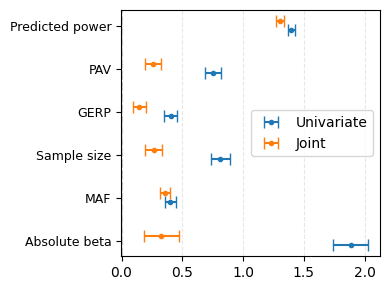

In [26]:
df = cluster_pleiotropy.toPandas()[
    [
        "uniqueTraitsInCluster",
        "maxAbsBeta",
        "maxMAF",
        "maxEffectiveSampleSize",
        "gerpNormalised",
        "vepScore",
        "predictedPower",
        "cluster_size",
    ]
].copy()

df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)

# Normalize covariates
for col in [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
    "maxEffectiveSampleSize",
    "predictedPower",
]:
    df[f"{col}Normalised"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

covariates_univariate = [
    "maxAbsBetaNormalised",
    "maxMAFNormalised",
    "maxEffectiveSampleSizeNormalised",
    "gerpNormalisedNormalised",
    "vepBinaryNormalised",
    "predictedPowerNormalised",
]
covariates_multi = [
    "maxAbsBetaNormalised",
    "maxMAFNormalised",
    "maxEffectiveSampleSizeNormalised",
    "gerpNormalisedNormalised",
    "vepBinaryNormalised",
    "predictedPowerNormalised",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueTraitsInCluster"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False, maxiter=1000)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueTraitsInCluster"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False, maxiter=1000)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)

# Print all results together
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])
print("\nMultiple regression results:")
print(multi_df.iloc[:, 0:4])
print(f"Pseudo R-squared: {model_multi.prsquared}")

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots(figsize=(4, 3))

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
new_labels = ["Absolute beta", "MAF", "Sample size", "GERP", "PAV", "Predicted power"]
ax.set_yticklabels(new_labels, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# 1. Full joint model
predicted_values = model_multi.predict(x_multi)
actual_values = y_multi
correlation = np.corrcoef(actual_values, predicted_values)[0, 1]
r_squared_full = correlation**2

# 2. Joint model without 'predictedPower'
covariates_multi_new = [
    "maxAbsBetaNormalised",
    "maxMAFNormalised",
    "maxEffectiveSampleSizeNormalised",
    "gerpNormalisedNormalised",
    "vepBinaryNormalised",
]
x_multi_new = df[covariates_multi_new].copy()
x_multi_new = sm.add_constant(x_multi_new)
y_multi = df["uniqueTraitsInCluster"]
model_multi_new = sm.NegativeBinomial(y_multi, x_multi_new).fit(
    disp=False, maxiter=1000
)

predicted_multi_new = model_multi_new.predict(x_multi_new)
actual_multi = y_multi
correlation_multi_new = np.corrcoef(actual_multi, predicted_multi_new)[0, 1]
r_squared_multi_new = correlation_multi_new**2


# 3. Univariate model with 'maxEffectiveSampleSize'
x_uni_sample_size = df[["maxEffectiveSampleSizeNormalised"]].copy()
x_uni_sample_size = sm.add_constant(x_uni_sample_size)
y_uni = df["uniqueTraitsInCluster"]
model_uni_sample_size = sm.NegativeBinomial(y_uni, x_uni_sample_size).fit(
    disp=False, maxiter=1000
)

predicted_uni = model_uni_sample_size.predict(x_uni_sample_size)
actual_uni = y_uni
correlation_uni = np.corrcoef(actual_uni, predicted_uni)[0, 1]
r_squared_uni = correlation_uni**2

print(f"Pearson R-squared for full joint model: {r_squared_full}")
print(
    f"Pearson R-squared for joint model without 'predictedPower': {r_squared_multi_new}"
)
print(
    f"Pearson R-squared for univariate model with 'maxEffectiveSampleSize': {r_squared_uni}"
)


Pearson R-squared for full joint model: 0.17732233634295996
Pearson R-squared for joint model without 'predictedPower': 0.060022097133018634
Pearson R-squared for univariate model with 'maxEffectiveSampleSize': 0.004450065814510142


In [28]:
df["predicted_traits_full_model"] = predicted_values
df["predicted_traits_no_power"] = predicted_multi_new
df

,uniqueTraitsInCluster,maxAbsBeta,maxMAF,maxEffectiveSampleSize,gerpNormalised,vepScore,predictedPower,cluster_size,vepBinary,maxAbsBetaNormalised,maxMAFNormalised,gerpNormalisedNormalised,vepBinaryNormalised,maxEffectiveSampleSizeNormalised,predictedPowerNormalised,predicted_traits_full_model,predicted_traits_no_power
0,122,0.222878,0.497881,4.963807e+05,0.237167,0.00,1.000000,402,0,0.072246,0.995761,0.237167,0.0,0.249194,1.000000,6.262827,3.250174
1,116,0.603285,0.422829,7.655914e+05,0.983750,0.10,1.000000,296,0,0.201565,0.845632,0.983750,0.0,0.384436,1.000000,7.166703,5.221729
2,113,1.335100,0.220463,1.778690e+06,0.847500,0.66,1.000000,278,1,0.450343,0.440830,0.847500,1.0,0.893383,1.000000,9.769357,16.951254
3,112,0.518454,0.409984,4.681218e+05,0.257826,0.10,1.000000,367,0,0.172726,0.819937,0.257826,0.0,0.234997,1.000000,6.074991,3.660328
4,110,0.291779,0.485770,4.384475e+05,0.754375,0.66,1.000000,282,1,0.095669,0.971534,0.754375,1.0,0.220090,1.000000,8.675911,5.756608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20036,1,0.052943,0.193592,8.958924e+04,0.000000,0.10,0.001103,1,0,0.014477,0.387079,0.000000,0.0,0.044835,0.000022,1.227565,1.514282
20037,1,0.133587,0.015157,1.471059e+05,0.750625,0.10,0.001101,1,0,0.041892,0.030149,0.750625,0.0,0.073730,0.000020,1.227481,1.516017
20038,1,0.066011,0.350973,3.940620e+04,0.434750,0.10,0.001092,1,0,0.018919,0.701895,0.434750,0.0,0.019625,0.000011,1.457063,2.018832
20039,1,0.085537,0.451253,2.158438e+04,0.000000,0.10,0.001091,1,0,0.025557,0.902490,0.000000,0.0,0.010672,0.000010,1.467750,2.135879


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_41267/3744163546.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



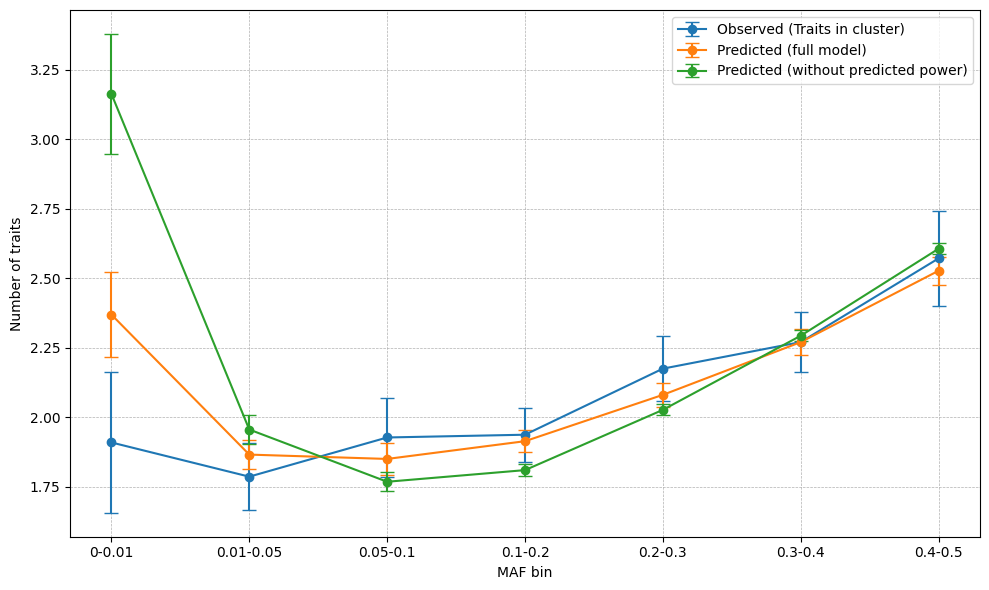

In [29]:
# Define the bins for maxMAF
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ["0-0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5"]
df["maxMAF_bin"] = pd.cut(df["maxMAF"], bins=bins, labels=labels, right=False)

# Group by the new bins and calculate mean and standard error of the mean
binned_data = (
    df.groupby("maxMAF_bin")
    .agg(
        observed_mean=("uniqueTraitsInCluster", "mean"),
        observed_sem=("uniqueTraitsInCluster", "sem"),
        predicted_full_mean=("predicted_traits_full_model", "mean"),
        predicted_full_sem=("predicted_traits_full_model", "sem"),
        predicted_no_power_mean=("predicted_traits_no_power", "mean"),
        predicted_no_power_sem=("predicted_traits_no_power", "sem"),
    )
    .reset_index()
)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Observed
ax.errorbar(
    binned_data["maxMAF_bin"],
    binned_data["observed_mean"],
    yerr=binned_data["observed_sem"] * 1.96,
    fmt="-o",
    label="Observed (Traits in cluster)",
    capsize=5,
)

# Plot Predicted (full model)
ax.errorbar(
    binned_data["maxMAF_bin"],
    binned_data["predicted_full_mean"],
    yerr=binned_data["predicted_full_sem"] * 1.96,
    fmt="-o",
    label="Predicted (full model)",
    capsize=5,
)

# Plot Predicted (without predicted power)
ax.errorbar(
    binned_data["maxMAF_bin"],
    binned_data["predicted_no_power_mean"],
    yerr=binned_data["predicted_no_power_sem"] * 1.96,
    fmt="-o",
    label="Predicted (without predicted power)",
    capsize=5,
)

# Set labels and title
ax.set_xlabel("MAF bin")
ax.set_ylabel("Number of traits")
ax.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [30]:
df

,uniqueTraitsInCluster,maxAbsBeta,maxMAF,maxEffectiveSampleSize,gerpNormalised,vepScore,predictedPower,cluster_size,vepBinary,maxAbsBetaNormalised,maxMAFNormalised,gerpNormalisedNormalised,vepBinaryNormalised,maxEffectiveSampleSizeNormalised,predictedPowerNormalised,predicted_traits_full_model,predicted_traits_no_power,maxMAF_bin
0,122,0.222878,0.497881,4.963807e+05,0.237167,0.00,1.000000,402,0,0.072246,0.995761,0.237167,0.0,0.249194,1.000000,6.262827,3.250174,0.4-0.5
1,116,0.603285,0.422829,7.655914e+05,0.983750,0.10,1.000000,296,0,0.201565,0.845632,0.983750,0.0,0.384436,1.000000,7.166703,5.221729,0.4-0.5
2,113,1.335100,0.220463,1.778690e+06,0.847500,0.66,1.000000,278,1,0.450343,0.440830,0.847500,1.0,0.893383,1.000000,9.769357,16.951254,0.2-0.3
3,112,0.518454,0.409984,4.681218e+05,0.257826,0.10,1.000000,367,0,0.172726,0.819937,0.257826,0.0,0.234997,1.000000,6.074991,3.660328,0.4-0.5
4,110,0.291779,0.485770,4.384475e+05,0.754375,0.66,1.000000,282,1,0.095669,0.971534,0.754375,1.0,0.220090,1.000000,8.675911,5.756608,0.4-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20036,1,0.052943,0.193592,8.958924e+04,0.000000,0.10,0.001103,1,0,0.014477,0.387079,0.000000,0.0,0.044835,0.000022,1.227565,1.514282,0.1-0.2
20037,1,0.133587,0.015157,1.471059e+05,0.750625,0.10,0.001101,1,0,0.041892,0.030149,0.750625,0.0,0.073730,0.000020,1.227481,1.516017,0.01-0.05
20038,1,0.066011,0.350973,3.940620e+04,0.434750,0.10,0.001092,1,0,0.018919,0.701895,0.434750,0.0,0.019625,0.000011,1.457063,2.018832,0.3-0.4
20039,1,0.085537,0.451253,2.158438e+04,0.000000,0.10,0.001091,1,0,0.025557,0.902490,0.000000,0.0,0.010672,0.000010,1.467750,2.135879,0.4-0.5


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_41267/1966955231.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



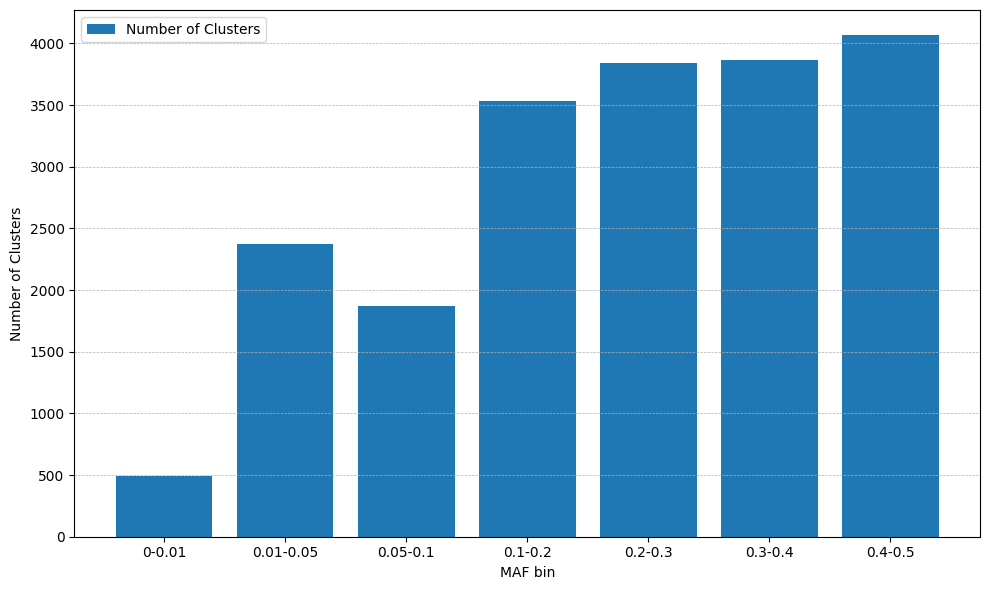

In [31]:
# Count the number of clusters in each MAF bin
cluster_counts = df.groupby("maxMAF_bin").size().reset_index(name="count")

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot as a bar chart
ax.bar(
    cluster_counts["maxMAF_bin"], cluster_counts["count"], label="Number of Clusters"
)

# Set labels and title
ax.set_xlabel("MAF bin")
ax.set_ylabel("Number of Clusters")
ax.legend()
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_41267/3033201452.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



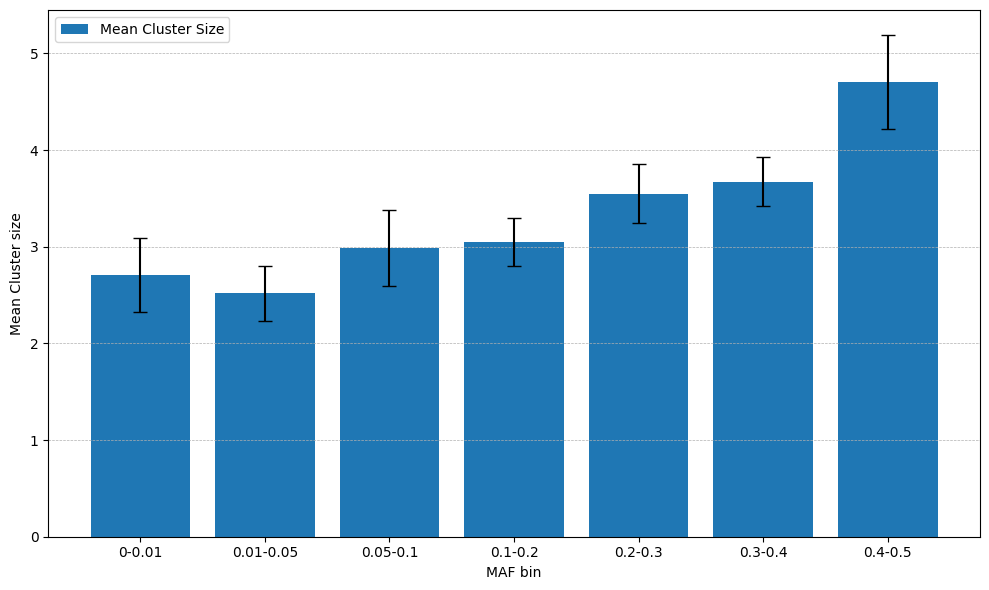

In [32]:
# Group by the new bins and calculate mean and standard error of the mean for cluster_size
binned_data_cluster_size = (
    df.groupby("maxMAF_bin")
    .agg(
        cluster_size_mean=("cluster_size", "mean"),
        cluster_size_sem=("cluster_size", "sem"),
    )
    .reset_index()
)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Observed as a bar chart
ax.bar(
    binned_data_cluster_size["maxMAF_bin"],
    binned_data_cluster_size["cluster_size_mean"],
    yerr=binned_data_cluster_size["cluster_size_sem"] * 1.96,
    capsize=5,
    label="Mean Cluster Size",
)

# Set labels and title
ax.set_xlabel("MAF bin")
ax.set_ylabel("Mean Cluster size")
ax.legend()
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [38]:
cluster_pleiotropy.count()

20041

In [ ]:
cluster_pleiotropy.filter(
    f.col("clusterNumberTherapeuticAreas") > 1
).count() / cluster_pleiotropy.count()

0.22633601117708696

In [ ]:
cluster_pleiotropy.filter(
    f.col("uniqueTraitsInCluster") > 1
).count() / cluster_pleiotropy.count()

0.3332169053440447

In [ ]:
cluster_pleiotropy.filter(
    f.col("cluster_size") > 1
).count() / cluster_pleiotropy.count()

0.40596776607953694